# 16.5.1 局部通信与平均一致

## 学习目标与先修知识

从图上的邻居差构造同步更新（synchronous update），并检查均值与连通分量（connected component）。

先修：11.2 图拉普拉斯（graph Laplacian）与守恒；矩阵（matrix）特征值（eigenvalue）。

## 具体问题

多个局部调节单元只能读取邻居总量，怎样在无向网络上逐步接近共同值？如果网络断开，能否全网一致？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型（model）对照。

In [2]:
x=np.array([0.,2.,4.]);W=np.array([[0.,1.,0.],[1.,0.,1.],[0.,1.,0.]]);print("一次局部交换：",x+.2*(W@x-W.sum(axis=1)*x))

一次局部交换： [0.4 2.  3.6]


## 模型假设

W 对称、非负且对角为零，权重单位1/T；状态（state） U，h 单位 T。同步更新使用全部旧状态。没有延迟（delay）与执行上限时，若 $0<h<2/\lambda_{\max}(L)$，非零拉普拉斯模态（mode）收缩；连通时达到全网平均。

## 数学解释与推导

离散一致性控制为 $x^+=(I-hL)x$，$L=\operatorname{diag}(W\mathbf1)-W$。无向图 $L=L^\mathsf T$、$\mathbf1^\mathsf TL=0$，故总和及均值守恒。若图连通，零特征值（zero eigenvalue）简单，其余特征值正；$|1-h\lambda_i|<1$ 使差异收缩。断连时每个分量保持自己的平均，不能声称全网算术平均一致。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def consensus_step(states,weights,h):
    x=np.asarray(states,dtype=float);W=np.asarray(weights,dtype=float)
    return (x+h*(W@x-W.sum(axis=1)*x)).tolist()


def consensus_path(states,weights,h,steps):
    history=[list(states)]
    for _ in range(steps):
        history.append(consensus_step(history[-1],weights,h))
    return history

## 对照实验

改变已声明的条件并比较曲线与数值。

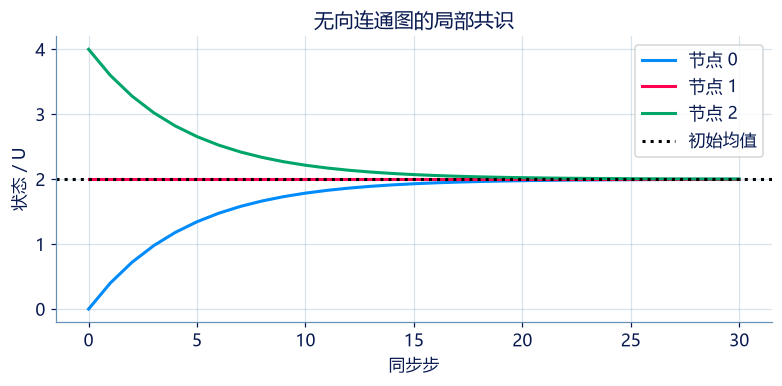

In [4]:
W=[[0.,1.,0.],[1.,0.,1.],[0.,1.,0.]];history=np.asarray(consensus_path([0.,2.,4.],W,.2,30))
fig,ax=plt.subplots(figsize=(7,3.4))
for j,color in enumerate([BLUE,PINK,GREEN]):ax.plot(history[:,j],label=f"节点 {j}",color=color)
ax.axhline(2.,color="black",ls=":",label="初始均值");ax.set(xlabel="同步步",ylabel="状态 / U",title="无向连通图的局部共识");ax.legend();ax.grid(alpha=.25);plt.show()

## 结果解释

这张无向连通图逐渐靠近初始平均；它不支持任意有向通信图都趋于算术平均的说法。断开边后应按各连通分量独立检查。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
np.testing.assert_allclose(history.sum(axis=1),6.,atol=1e-12)
assert abs(history[-1,0]-2)<.01
Wcut=[[0,1,0],[1,0,0],[0,0,0]];cut=np.asarray(consensus_path([0.,2.,4.],Wcut,.2,30))
np.testing.assert_allclose(cut[-1,2],4.)
print("总和、连通平均与孤立节点核验通过。")

总和、连通平均与孤立节点核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/16-05-%E5%88%86%E5%B8%83%E5%BC%8F%E6%8E%A7%E5%88%B6%E4%B8%8E%E9%80%9A%E4%BF%A1%E9%99%90%E5%88%B6/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：平均守恒的条件

无向对称图的 x⁺=(I-hL)x，为何平均保持？

- **A.** 1ᵀL=0，所有节点增量和为零。
- **B.** 每个节点从不变化。
- **C.** h 必须等于0。
- **D.** 只因画出平滑线。

[作答：平均守恒的条件](http://127.0.0.1:8000/chapters/16-05-%E5%88%86%E5%B8%83%E5%BC%8F%E6%8E%A7%E5%88%B6%E4%B8%8E%E9%80%9A%E4%BF%A1%E9%99%90%E5%88%B6/practice/?question=p16-symmetric-average)

### 第 2 题 · 单项选择题：断连网络的极限

无向网络分成两个连通分量（connected component）时，满足适当步长后可保证什么？

- **A.** 所有节点趋于全网平均。
- **B.** 各分量分别趋于其初始平均。
- **C.** 所有状态（state）保持初始值。
- **D.** 节点顺序自动重新连接。

[作答：断连网络的极限](http://127.0.0.1:8000/chapters/16-05-%E5%88%86%E5%B8%83%E5%BC%8F%E6%8E%A7%E5%88%B6%E4%B8%8E%E9%80%9A%E4%BF%A1%E9%99%90%E5%88%B6/practice/?question=p16-disconnected)

### 第 3 题 · Python 计算题：一次局部一致性更新

无向加权图每个节点只与邻居交换，返回一次 x+h(Wx-Dx)。

**函数与代码模板**

```python
def solve(
    states: list[float],
    weights: list[list[float]],
    h: float,
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | 各节点当前状态（state）。 | U |
| `weights` | `list[list[float]]` | 对称、非负、零对角的边权矩阵（matrix）。 | 1/T |
| `h` | `float` | 步长。 | T |

**返回值**

直接返回 next_states（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `next_states` | `list[float]` | 一步后各节点状态。 | U |

**计算规则**

每个节点按旧状态同步更新（synchronous update） x_i+h*Σ_j weights[i][j]*(x_j-x_i)。

**约束与边界**

- 2—10 个节点；矩阵对称、非负、零对角；h>0，全部有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| states | 各节点当前状态（state）。 | [0.0, 2.0] | U |
| weights | 对称、非负、零对角的边权矩阵（matrix）。 | [[0.0, 1.0], [1.0, 0.0]] | 1/T |
| h | 步长。 | 0.25 | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
states = [0.0, 2.0]
weights = [[0.0, 1.0], [1.0, 0.0]]
h = 0.25

result = solve(states, weights, h)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| next_states | 一步后各节点状态。 | [0.5, 1.5] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.5, 1.5]
```

**样例解释**

两节点例中互相向对方移动0.5，结果为0.5和1.5，平均仍为1。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：一次局部一致性更新](http://127.0.0.1:8000/chapters/16-05-%E5%88%86%E5%B8%83%E5%BC%8F%E6%8E%A7%E5%88%B6%E4%B8%8E%E9%80%9A%E4%BF%A1%E9%99%90%E5%88%B6/practice/?question=p16-local-consensus)

### 第 4 题 · Python 计算题：断连图的一致性路径

按给定对称权重重复局部更新，返回包含初态的路径。

**函数与代码模板**

```python
def solve(
    states: list[float],
    weights: list[list[float]],
    h: float,
    steps: int,
) -> list[list[float]]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | 各节点初态。 | U |
| `weights` | `list[list[float]]` | 无向权重。 | 1/T |
| `h` | `float` | 步长。 | T |
| `steps` | `int` | 更新次数。 | 步 |

**返回值**

直接返回 history（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `history` | `list[list[float]]` | 含初态的逐步状态（state）。 | U |

**计算规则**

对同一无向权重重复同步更新（synchronous update），路径包含初态。

**约束与边界**

- 2—10 个节点，0≤steps≤100；矩阵（matrix）对称、非负、零对角，h>0，全部有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| states | 各节点初态。 | [0.0, 2.0] | U |
| weights | 无向权重。 | [[0.0, 1.0], [1.0, 0.0]] | 1/T |
| h | 步长。 | 0.25 | T |
| steps | 更新次数。 | 2 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
states = [0.0, 2.0]
weights = [[0.0, 1.0], [1.0, 0.0]]
h = 0.25
steps = 2

result = solve(states, weights, h, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| history | 含初态的逐步状态（state）。 | [[0.0, 2.0], [0.5, 1.5], [0.75, 1.25]] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[0.0, 2.0], [0.5, 1.5], [0.75, 1.25]]
```

**样例解释**

首例首步为[0.5,1.5]，第二步为[0.75,1.25]；孤立节点不变。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：断连图的一致性路径](http://127.0.0.1:8000/chapters/16-05-%E5%88%86%E5%B8%83%E5%BC%8F%E6%8E%A7%E5%88%B6%E4%B8%8E%E9%80%9A%E4%BF%A1%E9%99%90%E5%88%B6/practice/?question=p16-component-average)

**进一步阅读**

[Olfati-Saber、Fax 与 Murray](https://www.cds.caltech.edu/~murray/papers/2007c_ofm07-ieeeproc.html)讨论通信拓扑与一致性。